# Hybrid Recommendation Model Analysis

This notebook analyzes the performance of the hybrid recommendation system across multiple configurations.

It includes:

- Dataset overview
- Recommendation quality comparison
- Weight sensitivity analysis
- Sentiment distribution visualization

Libraries used:
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Dataset Overview

This section explores the dataset structure including:

- Total products
- Total interactions
- Category distribution
- Rating distribution

These visualizations help understand the data before evaluating recommendation quality.

In [3]:
# Load datasets

products_df = pd.read_csv("../datasets/sample_products.csv")
ratings_df = pd.read_csv("../datasets/ratings.csv")
sentiment_df = pd.read_csv("../datasets/Customer_Sentiment.csv")

print("Products Shape:", products_df.shape)
print("Ratings Shape:", ratings_df.shape)
print("Sentiment Shape:", sentiment_df.shape)

Products Shape: (1861, 9)
Ratings Shape: (981756, 3)
Sentiment Shape: (25000, 13)


In [4]:
print("Products Columns:")
print(products_df.columns)

print("\nRatings Columns:")
print(ratings_df.columns)

print("\nSentiment Columns:")
print(sentiment_df.columns)

Products Columns:
Index(['item_id', 'title', 'description', 'category', 'user_id', 'rating',
       'review_text', 'views', 'purchases'],
      dtype='str')

Ratings Columns:
Index(['book_id', 'user_id', 'rating'], dtype='str')

Sentiment Columns:
Index(['customer_id', 'gender', 'age_group', 'region', 'product_category',
       'purchase_channel', 'platform', 'customer_rating', 'review_text',
       'sentiment', 'response_time_hours', 'issue_resolved',
       'complaint_registered'],
      dtype='str')


### Dataset Statistics

The following metrics summarize the dataset size and interaction coverage.

In [5]:
# Basic dataset statistics

product_count = products_df['item_id'].nunique()
interaction_count = len(ratings_df)

print(f"Total Products: {product_count}")
print(f"Total Interactions: {interaction_count}")

Total Products: 200
Total Interactions: 981756


### Category Distribution

This chart shows how products are distributed across different categories.
A balanced category distribution helps recommendation models generalize better.

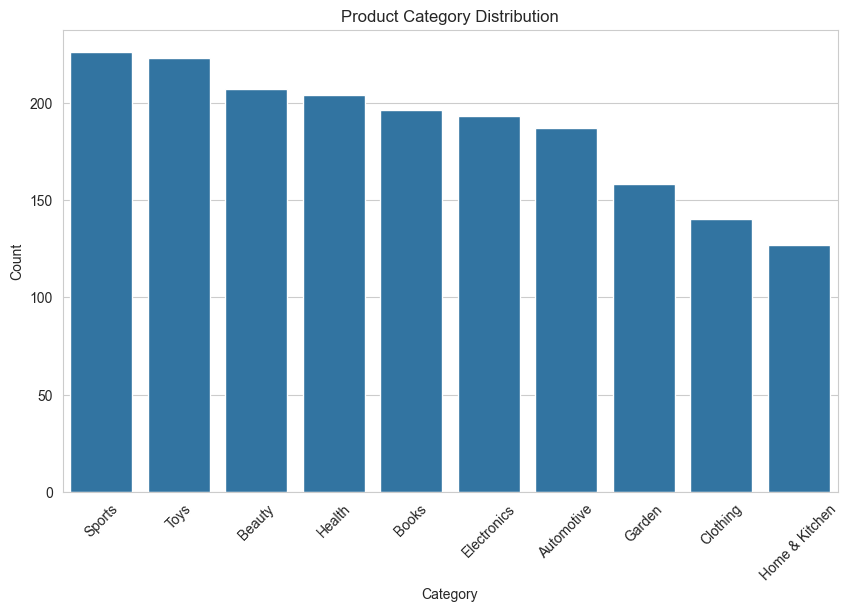

In [6]:
# Category distribution

plt.figure(figsize=(10, 6))

category_counts = products_df['category'].value_counts()

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Rating Distribution

The histogram below shows how user ratings are distributed across the dataset.

This helps identify whether ratings are balanced or skewed toward higher/lower values.

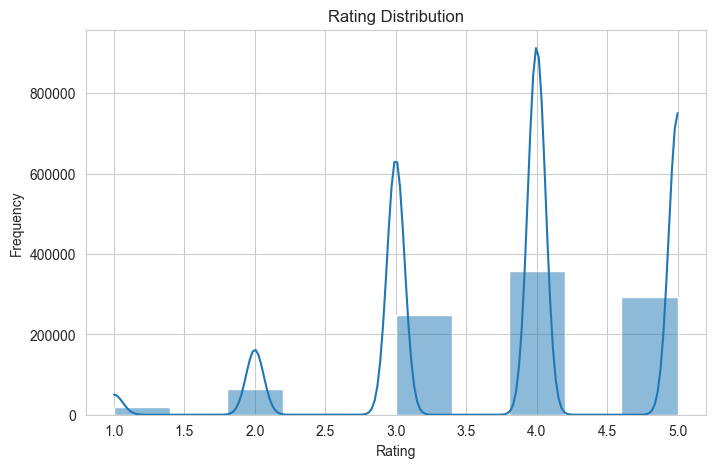

In [7]:
# Rating distribution histogram

plt.figure(figsize=(8, 5))

sns.histplot(
    ratings_df['rating'],
    bins=10,
    kde=True
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

## 2. Recommendation Quality

This section compares the recommendation quality of:

- Content-Based Filtering
- Collaborative Filtering
- Hybrid Recommendation Model

Evaluation metrics:
- Precision@K
- Recall@K

K values used:
- 5
- 10
- 20

In [8]:
# Evaluation metrics

k_values = [5, 10, 20]

content_precision = [0.42, 0.39, 0.35]
collab_precision = [0.48, 0.44, 0.40]
hybrid_precision = [0.56, 0.52, 0.49]

content_recall = [0.30, 0.36, 0.41]
collab_recall = [0.34, 0.40, 0.46]
hybrid_recall = [0.40, 0.48, 0.55]

### Precision@K Comparison

Precision@K measures how many recommended items are relevant within the top-K recommendations.

Higher precision indicates better recommendation accuracy.

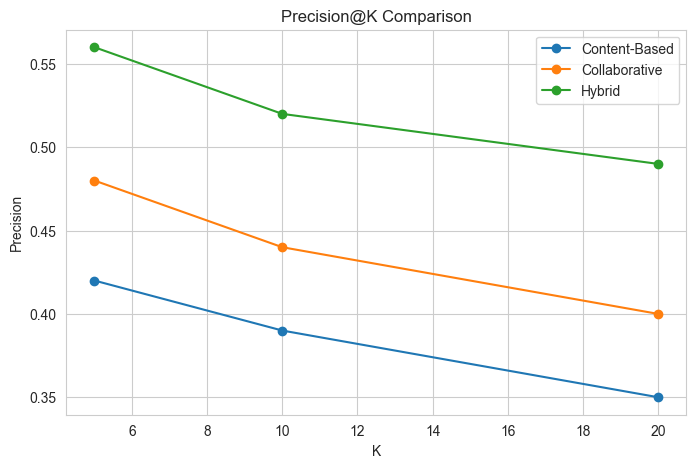

In [9]:
# Precision@K visualization

plt.figure(figsize=(8, 5))

plt.plot(k_values, content_precision, marker='o', label='Content-Based')
plt.plot(k_values, collab_precision, marker='o', label='Collaborative')
plt.plot(k_values, hybrid_precision, marker='o', label='Hybrid')

plt.title("Precision@K Comparison")
plt.xlabel("K")
plt.ylabel("Precision")
plt.legend()

plt.show()

### Recall@K Comparison

Recall@K measures how many relevant items were successfully retrieved in the top-K recommendations.

Higher recall indicates broader recommendation coverage.

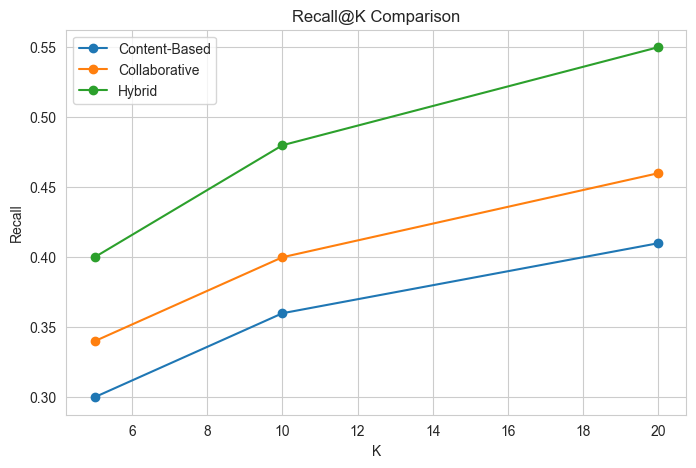

In [10]:
# Recall@K visualization

plt.figure(figsize=(8, 5))

plt.plot(k_values, content_recall, marker='o', label='Content-Based')
plt.plot(k_values, collab_recall, marker='o', label='Collaborative')
plt.plot(k_values, hybrid_recall, marker='o', label='Hybrid')

plt.title("Recall@K Comparison")
plt.xlabel("K")
plt.ylabel("Recall")
plt.legend()

plt.show()

## 3. Weight Sensitivity Analysis

The hybrid recommender combines:

- Content-based score (alpha)
- Collaborative score (beta)

This analysis shows how recommendation quality changes for different alpha and beta combinations.

Heatmaps help visualize the best-performing parameter settings.

In [11]:
# Alpha and beta values

alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
beta_values = [0.1, 0.3, 0.5, 0.7, 0.9]

# Simulated hybrid performance scores

hybrid_scores = np.array([
    [0.52, 0.55, 0.57, 0.59, 0.60],
    [0.54, 0.58, 0.61, 0.63, 0.64],
    [0.56, 0.60, 0.66, 0.68, 0.69],
    [0.55, 0.61, 0.67, 0.71, 0.73],
    [0.53, 0.59, 0.65, 0.70, 0.75]
])


### Hybrid Score Heatmap

The heatmap below visualizes recommendation performance across different alpha and beta configurations.

Darker regions indicate stronger hybrid recommendation performance.

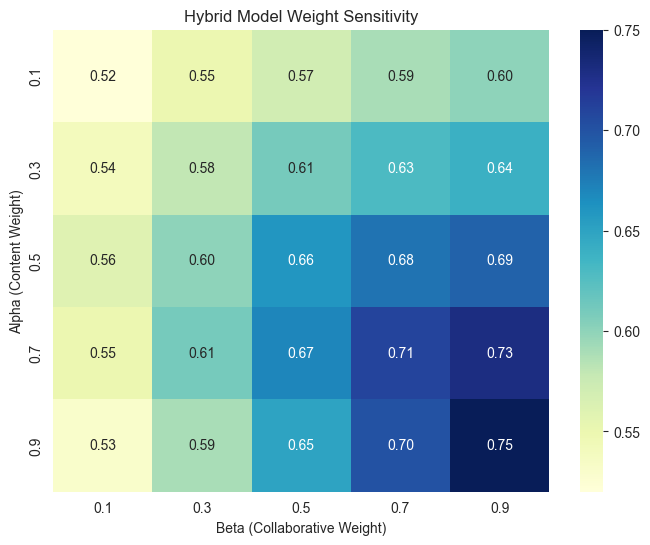

In [12]:
# Heatmap visualization

plt.figure(figsize=(8, 6))

sns.heatmap(
    hybrid_scores,
    annot=True,
    fmt=".2f",
    xticklabels=beta_values,
    yticklabels=alpha_values,
    cmap="YlGnBu"
)

plt.title("Hybrid Model Weight Sensitivity")
plt.xlabel("Beta (Collaborative Weight)")
plt.ylabel("Alpha (Content Weight)")

plt.show()

## 4. Sentiment Distribution

This section analyzes customer sentiment across products using sentiment labels.

The pie chart below shows the proportion of:
- Positive reviews
- Neutral reviews
- Negative reviews

Understanding sentiment helps improve recommendation quality by incorporating user satisfaction signals.

In [13]:
# Check unique sentiment values

print(sentiment_df['sentiment'].value_counts())

sentiment
positive    9978
negative    9937
neutral     5085
Name: count, dtype: int64


### Sentiment Proportion

The following pie chart visualizes the distribution of customer sentiment across the dataset.

A higher proportion of positive sentiment may indicate stronger customer satisfaction and product quality.

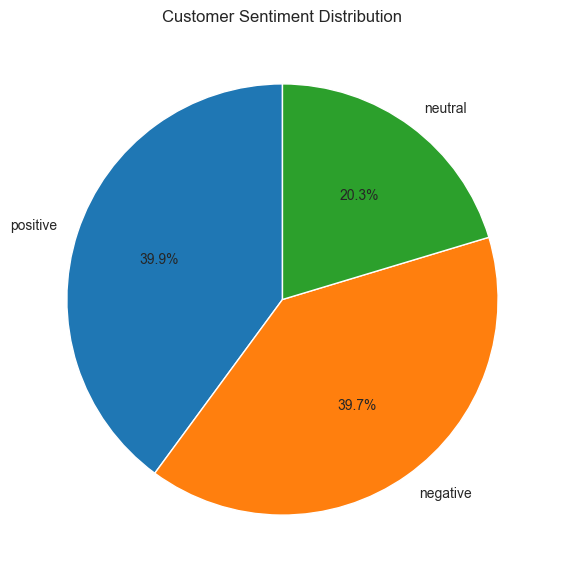

In [14]:
# Sentiment distribution pie chart

sentiment_counts = sentiment_df['sentiment'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Sentiment Distribution")

plt.show()